# Calculus
Quando parliamo di ottimizziazione intendiamo ottimizzare i parametri del modello in base ai dati di addestramento, qui gli argomenti che vedremo ora saranno fondamentali.
Il nostro obiettivo finale rimane però quello di far performare bene il modello in dati mai visti prima, questo problam si chiama _generalizzazione_.

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
import torch

## Deviratives and Differentiation
Vista in modo semplice la derivata di una funzione ci indica quanto velocemente cambia una funzione rispetto ai suoi argomenti, ci indica ad esempio quanto rapidamente una loss function sta aumentando o diminuendo quando incrementiamo o decrementiamo un parametro.
Formalmente per delle funzioni $f:\mathbb{R}\to\mathbb{R}$ la derivata in un punto $x$ è data da $$f'(x)=\lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$$

Quando facciamo $f(x+h)$ stiamo compiendo un piccolo passo $h$ mentre ci troviamo su $x$, facendo invece la sottrazione $f(x+h)-f(x)$ stiamo appunto calcolando quanto ci siamo mossi, dividendo per il passo fatto $h$ calcoliamo la pendenza in quel punto. Impostando il limite a 0 otteniamo appunto la tangente in quel punto.

Quando $f'(x)$ esiste $f$ si dice differenziabile su $x$ e quando $f'(x)$ esiste per ogni $x$ di un insieme allora diciamo che $f$ è differenziabile su quel set. Non tutte le funzioni sono differenziabili, ad esempio una rete che ha come risposte soltanto solo 1 e 0 avrà molti scatti e non possiamo calcolare le tangenti, ma siccome calcolare la derivata è un passo cruciale nel deep learning risolviamo la situazione con una surrogata differenziabile.

Iniziamo a vedere un esempio $u=f(x)=3x^2-4x$

In [5]:
def f(x):
    return 3 * x ** 2 - 4 * x

Ad esempio impostando $x=1$ e calcolando il limite per $h$ che tende a 0 notiamo che $f'(1)=2$

Infatti se scriviamo una funzione che ci calcola questo limite, diminuendo sempre $h$:

In [7]:
for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


Esistono tantissime notazioni per indicare le derivate, data una $y=f(x)$ tutte le seguenti espressioni sono equivalenti. pd i matematici che inventano 20 notazioni per la stessa cosa
$$f'(x)=y'=\frac{dy}{dx}=\frac{df}{dx}=\frac{d}{dx}f(x)=Df(x)=D_xf(x)$$

I simboli $\frac{d}{dx}$ e $D$ sono i _differentiation operators_, inoltre non dobbiamo sempre calcolare i limiti ma ci sono delle regole per alcune funzioni:
- $\frac{d}{dx}C=0$ per ogni costante $C$
- $\frac{d}{dx}x^n=nx^{n-1}$ per $n\neq 0$
- $\frac{d}{dx}e^x=e^x$
- $\frac{d}{dx}ln x = x^{-1}$

Spesso funzioni composte da funzioni differenziabili sono anch'esse differenziabili, esistono delle regole anche per questi casi
- $\frac{d}{dx}[Cf(x)]=C\frac{d}{dx}f(x)$ Constant multiple rule
- $\frac{d}{dx}[f(x)+g(x)]=\frac{d}{dx}f(x)+\frac{d}{dx}g(x)$ Sum rule
- $\frac{d}{dx}[f(x)g(x)=f(x)\frac{d}{dx}g(x)+g(x)\frac{d}{dx}f(x)$ Product rule
- $\frac{d}{dx}\frac{f(x)}{g(x)}=\frac{g(x)\frac{d}{dx}f(x)-f(x)\frac{d}{dx}g(x)}{g^2(x)}$ Quotient rule

Possiamo ad esempio utilizzerle per calcolare più velocemente il limite di prima $3x^2-4x$: $$\frac{d}{dx}[3x^2-4x]=3\frac{d}{dx}x^2 - 4\frac{d}{dx}x=6x-4$$

E appunto impostando $x=1$ otteniamo 2 come risultato.

## Visuallization Utilities
Per visualizzare le nostre funzioni abbiamo bisogno di alcune funzioni, la prima è `use_svg_display` che dice a matplotlib di esportare le immagini in SVG

In [8]:
def use_svg_display(): #@save
    backend_inline.set_matplotlib_formats('svg')

Possiamo poi impostare la grandezza delle immagini

In [9]:
def set_figsize(figsize=(3.5, 2.5)): #@save
    use_svg_display()
    plt.rcParams['figure.figsize'] = figsize

La funzione `set_axes` associa agli assi delle proprietà come label, range o altro

In [10]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

Con queste 3 funzioni definite possiamo definire un `plot` per mostrare le curve.

In [11]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

Adesso possiamo visualizzare la funzione $u=f(x)$ e la sua tangente $y=2x-3$ nel punto $x=1$

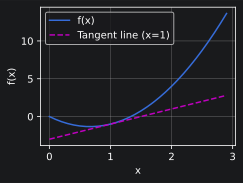

In [14]:
x = np.arange(0,3,0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

## Partial Derivatives and Gradients
Per ora abbiamo visto come derivare funzioni con una sola variabile, in deep learning però lavoreremo con funzioni che hanno molte variabili, iniziamo ad introdurre quindi questa nuova notazione.

Prendiamo $y=f(x_1,x_2,...,x_n)$ una funzione con $n$ variabili. La derivata parziale di $y$ rispetto al suo $i$-esimo parametro $x_i$ è $$\frac{\partial y}{\partial x_i}=\lim_{h\to 0} \frac{f(x_1,...,x_{i-1},x_i+h,x_{i+1},...,x_n)-f(x_1,...,x_i,...,x_n)}{h}$$

Per calcolare $\frac{\partial y}{\partial x_i}$ possiamo pensare a $x_1,...,x_{i-1},x_i + h, x_{i+1},...,x_n$ come una costante e calcolare la derivata di $y$ rispetto ad $x_i$, in questo modo ci siamo ridotti al problema di una singola derivata, che sappiamo già come calcolare. Le seguenti notazioni sono tutte equivalenti ed indicano la derivata parziale:
$$\frac{\partial y}{\partial x_i}=\frac{\partial f}{\partial x_i}=\partial_{x_i}f=\partial_i f= f_{x_i}=f_i=D_i f= D_{x_i}f$$
Possiamo concatenare le derivate parziali di una funzione con più parametro per ottenere un vettore chiamato **gradiente** della funzione. Supponiamo che l'input di una funzione $f:\mathbb{R}^n\to\mathbb{R}$ è un vettore $n$-dimensionale $\pmb{x}=[x_1,x_2,...,x_n]^T$ e l'output sia uno scalare. Il gradiente della funzione $f$ rispetto ad $\pmb{x}$ è un vettore di $n$ derivate parziali:
$$\nabla_{\pmb{x}}=f(\pmb{x})=[\partial_{x_1}f(\pmb{x}),\partial_{x_2}f(\pmb{x}),...,\partial_{x_n}f(\pmb{x})]^T$$

Quando non si crea ambiguità con le variabili, tipicamente scriviamo $\nabla f(\pmb{x})$ invece di $\nabla_{\pmb{x}}f(\pmb{x})$.
Ci sono delle proprietà che ci permettono di non dover fare sempre calcoli enormi:
- $\forall \pmb{A}\in\mathbb{R}^{m \times n}$ si ha che $\nabla_{\pmb{x}}\pmb{Ax}=\pmb{A}^T$ e $\nabla_{\pmb{x}}\pmb{x}^T\pmb{A}=\pmb{A}$ Il simbolo di traposizione serve solo per correttezza, la regola ci dice che la derivata è semplicemente $A$.
- Per matrici quadrate $\pmb{A}\in\mathbb{R}^{n\times n}$ abbiamo che $\nabla_{\pmb{x}}\pmb{x}^T\pmb{Ax}=(\pmb{A}+\pmb{A}^T)\pmb{x}$, questa sarebbe la classica regola delle derivate, infatti se la matrice è quadrata e la sua trasposta è uguale a se stessa otteniamo $(A+A)x=2Ax$. Un altro caso particolare è $\nabla_{\pmb{x}}||\pmb{x}||^2=\nabla_{\pmb{x}}\pmb{x}^T\pmb{x}=2\pmb{x}$, infatti se ricordiamo questo era semplicemente il teorema di pitagora quindi dobbiamo abbassare l'esponente a tutti i termini.

In modo simile all'ultima formula abbiamo anche che per ogni matrice $\pmb{X}$,$\nabla_{X}||\pmb{X}||^2_F=2\pmb{X}$


## Chain Rule
In Deep Learning i gradienti che ci interessano sono molto complicati da calcolare dato che lavorano in cicli molto innestati di funzioni (funzione di funzioni di funzioni di...). Fortunatamente abbiamo la _chain rule_ che ci aiuta. Torniamo per un attimo a funzioni con una sola variabile, ad esempio $y=f(g(x))$ e definiamo anche $y=f(u)$ e $u=g(x)$, queste sono entrambe derivabili. La chain rule ci dice che:
$$\frac{dy}{dx}=\frac{dy}{du}\frac{du}{dx}$$

Quello che ci dice la regola è, semplicemente, di moltiplicare fra loro le derivate.

Adesso però torniamo a lavorare con funzioni a più variabili, supponiamo $y=f(\pmb{u})$ e abbia quindi le variabili $u_1,u_2,...,u_m$ dove ogni $u_i=g_i(\pmb{x})$ che le variabili $x_1,x_2,...,x_n$ ovvero $\pmb{u}=g(\pmb{x})$. La chain rule ci dice che

$$\frac{\partial y}{\partial x_i}=\frac{\partial y}{\partial u_1}\frac{\partial u_1}{\partial x_i}+\frac{\partial y}{\partial u_2}\frac{\partial u_2}{\partial x_i}+...+\frac{\partial y}{\partial u_m}\frac{\partial u_m}{\partial x_i} \text{e quindi} \nabla_x y=\pmb{A}\nabla_u y$$

Dove $\pmb{A}\in\mathbb{R}^{n\times m}$ è una matrice che contiene le derivate del vettore $\pmb{u}$ rispetto al vettore $\pmb{x}$.

Spiegato in modo più generale, immaginiamo che la nostra rete debba controllare un'immagine e che appunto il vettore x contenga ogni pixel di quest'ultima. Ogni neurone della nostra rete, ovvero ogni $u_i$ dovrà guardare tutta l'immagine e ogni neurone sarà specializzato nel cercare qualcosa nella rete, ogni neurone $u_i$ userà quindi la funzione $g_i$ su tutto il vettore $x$. Una volta finito dovremo fare l'output finale ovvero vedere i calcoli fatti da questi neuroni e decidere ad esempio se nella foto c'è un gatto o un cane, per farlo non guarderemo più i singoli pixel ma il risultato parziale dei neuroni e quindi la funzione $f$ scorre tutto il vettore $u$.

In questo modo però notiamo che modificare un solo pixel modifica sia il risultato di tutti i neuroni sia il risultato finale, per sapere quindi come modificherà il risultato finale dobbiamo sommare tutti i possibili percorsi in cui l'informazione viaggia fino alla fine.
Quello che fa la regola della catena è proprio questo, calcola l'effetto di $x_i$ su $u_1$ moltiplicato per l'effetto di $u_1$ su $y$ poi somma l'effetto di $x_i$ su $u_2$ moltiplicato per l'effetto di $u_2$ su $y$ e così via.